# **ETTh1: Multi- to Univariate Squence-to-Squence Forecasting with LSTMs**
---

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from torch.utils.data import DataLoader, Dataset
from torch import nn

----
## **CHOOSE MODE & MAIN PARAMETERS**
----

In [2]:
# Set the notebook mode
mode = "testing"           # "training" OR "testing"

# checking
if mode not in ["training", "testing"]:
    raise ValueError("Mode must be set to either 'training' or 'testing'")

In [3]:
# Hyperparameter definition w/o Optuna tuning -- can be added later
context  = 96       # [hours]
forecast = 96       # [hours]
batch    = 64       # [samples]
lstm_hidden_layers = 2
lstm_hidden_size   = 17
optimizer_learningrate = 0.0001
epochs = 100

----
## **MODEL & CLASS DEFINITION**
----

### **Sample Datasets**



In [4]:
class Sample_Dataset(Dataset):

    def __init__(self, data: pd.DataFrame, context_length: int, forecast_length: int):

        # Converting DataFrame to numpy for better processing
        self.feature_data    = data.to_numpy(dtype=np.float32)          # input x -- depending on task this is either the whole training, validation or testing split
        self.target_data     = data["OT"].to_numpy(dtype=np.float32)    # prediction target y

        self.context_length  = context_length       # L [hours]
        self.forecast_length = forecast_length      # H [hours]


    def __len__(self):
        # Total number of samples in the dataset
        # S = 1, timestep or stride [hours] -- delta-t by which each sample moves along the time series relative to its predecessor.

        sample_qty = (self.feature_data.shape[0] - self.context_length - self.forecast_length) + 1      # = ((T-L-H)/S)+1 | the +1 comes from considering the first sample window before a single stride was made

        return sample_qty


    def __getitem__(self, sample_index):
        # Define what each sample looks like in terms of the data it contains: implement all data that is correlated and shall be fed to the model for learning them
        # Every sample is assigned an index, default is integers = 0, 1, 2, 3.... len(dataset)-1

        # x = sample input data = the full multivariate time series but restricted to the context length = only ranging from index to (index + context_length) (index = 0,1...!)
        x_inputs_array = self.feature_data[sample_index : (sample_index + self.context_length)]           # MIND! last value of that range is EXCLUDED, the first is INCLUDED

        # y = data of the correct correlated output that shall be predicted -- here: univariate output of OT from the data, but positioned behind the the training window and being as wide as the forecast window
        y_targets_array = self.target_data[(sample_index + self.context_length) : (sample_index + self.context_length + self.forecast_length)]     # MIND! last value of that range is EXCLUDED, the first is INCLUDED

        return torch.tensor(x_inputs_array), torch.tensor(y_targets_array)     # convert arrays into tensors for more predictable processing

### **DataLoader**
- using the PyTorch default, no need for custom implementations

### **Neural Net Design - LSTM**

In [5]:
class LSTM_ForecastModel(nn.Module):

    def __init__(self, num_input_features: int, lstm_width: int, lstm_depth: int, forecast_length: int):

        self.num_input_features = num_input_features   # multivariate input sequence: channel_number = features processed per timestep
        self.lstm_width         = lstm_width           # neurons per layer
        self.lstm_depth         = lstm_depth           # number of layers
        self.forecast_length    = forecast_length      # [hours] -- can be tuned as hyperparameter

        super().__init__()      # initializing the nn.Module parent class also


        # LSTM part of the NN
        self.lstm_network = nn.LSTM(
            input_size   = self.num_input_features,
            hidden_size  = self.lstm_width,
            num_layers   = self.lstm_depth,
            batch_first  = True,                         # batch size = first entry in the DataLoader outputs, typically True
            # dropout     = dropout       # 0.2 would mean roughly (20)% of the relevant activations are dropped during each training pass. can help avoid overfitting with large datasets
        )

        # Linear output layer for direct one-shot multi-timestep forecasting
        # --> Use only the output from the last timestep as projection to accumulate info in the LSTM state, discard other outputs --> see forward()
        self.output_layer = nn.Linear(
            in_features  = self.lstm_width,          # connecting to the last LSTM layer
            out_features = self.forecast_length      # projecting to the full forcast window at the same time
        )


    def forward(self, x_inputs):
        # perform the forward pass on itself by feeding inputs x
        # tensor from DataLoader: x_inputs.shape = (batch_size, context_length, num_input_features)

        lstm_output, _ = self.lstm_network(x_inputs)          # return structure: output, (h_n, c_n) = lstm(x) // output.shape == (batch_size, context_length, hidden_size)

        # select the last output for forecasting only, but all related batches and hidden features
        lstm_last_output = lstm_output[ : , -1, : ]    # indexation in the tensor: output[batch_index, time_index, hidden_size], starting with 0 -- means [:,context_length -1,:] or just [:,-1,:], remember counting starts with 0 so the last is context -1

        # make the forecasting projection with the last lstm outputs to the whole forecast horizon
        y_predictions = self.output_layer(lstm_last_output)

        return y_predictions     # shape: [batch_size, forecast_length, num_output_features = 1]

----
## **DATA PREPARATION**
----

### **Import**
The imported DataFrame has a shape of $ \mathrm{data\_ETTh1} \isin \R^{Tx7} $

In [6]:
# Import full data set from original source
url =  "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/refs/heads/main/ETT-small/ETTh1.csv"

data_ETTh1 = pd.read_csv(url, sep = ",")
data_ETTh1.set_index('date', inplace=True)

### **Splitting into Training/Validation/Test Sets**
- Using the recommended typical 12 - 4 - 4 split, resulting in a total of 20 months of data
- The dataset contains almost 24 months, so the remaining c. 4 months get cut and are **discarded**
- Validation and test datasets are extended so that x_val and x_test start in the training and validation set already

In [7]:
# Number of rows in the source ETTh1 data set
timesteps_source = data_ETTh1.shape[0]     # hours in the full length dataset (rows in the original data frame)
print("Timesteps in the source dataset: ", timesteps_source, "hours")

# Splitting into training, validation, and test splits
hours_per_month = 30 * 24                        # hours

training_length   = 12 * hours_per_month         # hours
validation_length = 4 * hours_per_month          # hours
test_length       = 4 * hours_per_month          # hours

# Create training, validation, and test splits
training_split    = data_ETTh1.iloc[:training_length]
validation_split  = data_ETTh1.iloc[training_length:(training_length + validation_length)]
test_split        = data_ETTh1.iloc[(training_length + validation_length):(training_length + validation_length + test_length)]
discarded_split   = data_ETTh1.iloc[(training_length + validation_length + test_length):]

timesteps = training_split.shape[0] + validation_split.shape[0] + test_split.shape[0]

print("Timesteps in the truncated split: ", timesteps, "hours")
print("Timesteps in the training split: ", training_split.shape[0], "hours")
print("Timesteps in the discarded split: ", discarded_split.shape[0], "hours")
print("The training/validation/test split relative to the truncated set [%]: ", training_split.shape[0]/timesteps*100, "/", validation_split.shape[0]/timesteps*100, "/", test_split.shape[0]/timesteps*100)

Timesteps in the source dataset:  17420 hours
Timesteps in the truncated split:  14400 hours
Timesteps in the training split:  8640 hours
Timesteps in the discarded split:  3020 hours
The training/validation/test split relative to the truncated set [%]:  60.0 / 20.0 / 20.0


In [8]:
# No changes needed
training_set = training_split

# Extending the validation split, x_val should start at -context in the training set, so first val_prediction is the first unseen entry in the validation split (moving window, see Dataset __getitem__!)
validation_set = pd.concat([ training_split.iloc[ -context : ], validation_split])

# Extending the testing split, respectively
test_set = pd.concat([ validation_split.iloc[ -context : ], test_split])

# Checking the
print(f"Validation split was extended by: {validation_set.shape[0] - validation_split.shape[0]} hours, must match the context window of {context} hours.")
print(f"Test split was extended by: {validation_set.shape[0] - validation_split.shape[0]} hours, must match the context window of {context} hours.")


Validation split was extended by: 96 hours, must match the context window of 96 hours.
Test split was extended by: 96 hours, must match the context window of 96 hours.


### **Scaling the Training Set, Fitting Validation & Test Sets for each Channel**
- Each channel has a different characteristic and must be scaled separately
- Chosing the MinMaxScaler over the StandardScaler because it allows to bound all signals to a fixed interval of magnitudes: no channel shall introduce overfitting due to pure differences in magnitude --> feels "cleaner" for multivariate inputs.
- Choosing (-1,1) as interval for the MinMaxScaler for neutral signal processing

In [9]:
# Set up empty DataFrames to hold the scaled data with the right index and columns
training_set_scaled = pd.DataFrame(index=training_set.index, columns=training_set.columns)
validation_set_scaled = pd.DataFrame(index=validation_set.index, columns=validation_set.columns)
test_set_scaled = pd.DataFrame(index=test_set.index, columns=test_set.columns)

# Initialize a dictionary to store the specific scaler for each channel
scalers_dict = {}

for column in training_set.columns:

    # Define and fit the scaler on the training set of each signal only
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler.fit(training_set[[column]])

    # Save this column's scaler for later inverse transformation of predictions
    scalers_dict[column] = scaler

    # Transform the training, validation, and test sets of each signal using the fitted scaler. All set have the same index and columns as the original data frames.
    training_set_scaled[column] = scaler.transform(training_set[[column]])
    validation_set_scaled[column] = scaler.transform(validation_set[[column]])
    test_set_scaled[column] = scaler.transform(test_set[[column]])

array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>], dtype=object)

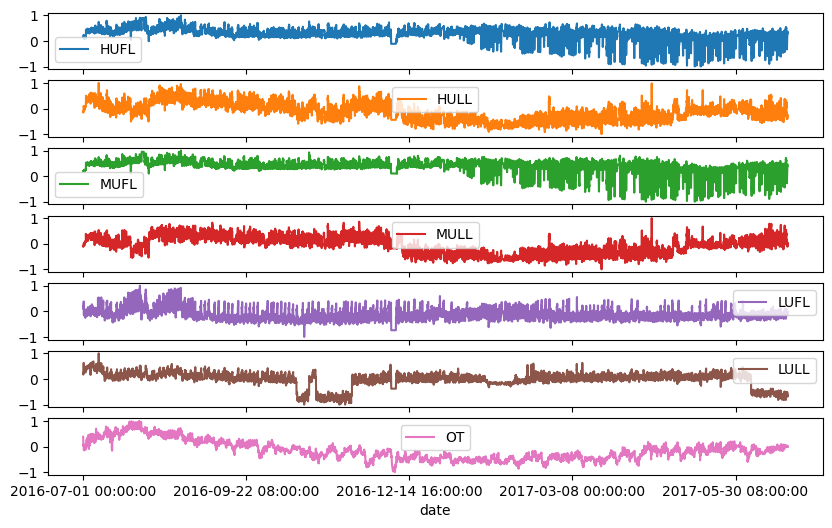

In [10]:
# Checking results of scaling
training_set_scaled.plot(subplots=True, figsize=(10, 6))

### **Create Data Samples and Batches**

In [11]:
# Initialize data sampling
training_dataset = Sample_Dataset(
    data            = training_set_scaled,
    context_length  = context,
    forecast_length = forecast
)

validation_dataset = Sample_Dataset(
    data            = validation_set_scaled,
    context_length  = context,
    forecast_length = forecast
)

test_dataset = Sample_Dataset(
    data            = test_set_scaled,
    context_length  = context,
    forecast_length = forecast
)

# Load samples and initialize batches
training_batches = DataLoader(
    dataset    = training_dataset,
    batch_size = batch,
    shuffle    = True
)

validation_batches = DataLoader(
    dataset    = validation_dataset,
    batch_size = batch,
    shuffle    = False
)

test_batches = DataLoader(
    dataset    = test_dataset,
    batch_size = batch,
    shuffle    = False
)

# Shape check: extract batches for x_inputs and y_targets data
x_inputs_batch, y_targets_batch = next(iter(training_batches))

print("Input shape:", x_inputs_batch.shape)
print("Target shape:", y_targets_batch.shape)
print("Number of batches:", len(training_batches))

Input shape: torch.Size([64, 96, 7])
Target shape: torch.Size([64, 96])
Number of batches: 133


----
## **TRAINING**
----

### **Model Initialization**

In [12]:
# Initialize the model
model = LSTM_ForecastModel(
    num_input_features = training_set_scaled.shape[1],  # columns in the input dataframe
    lstm_width         = lstm_hidden_size,
    lstm_depth         = lstm_hidden_layers,
    forecast_length    = forecast
)

### Print number of trainable parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model has {num_params} trainable parameters.")

# Select device for computations
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Execute model on defined device
model.to(device)

Model has 5944 trainable parameters.
Device: cpu


LSTM_ForecastModel(
  (lstm_network): LSTM(7, 17, num_layers=2, batch_first=True)
  (output_layer): Linear(in_features=17, out_features=96, bias=True)
)

### **Loss Function & Optimization**

In [13]:
# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=optimizer_learningrate,
)

### **Model Training & Validation Loop**

In [14]:
if mode == "training":

    training_losses = []
    validation_losses = []

    for epoch in range(epochs):

        # Training Step
        model.train()
        epoch_training_loss_sum = 0.0

        for x_training_batch, y_training_targets_batch in training_batches:

            x_training_batch         = x_training_batch.to(device)
            y_training_targets_batch = y_training_targets_batch.to(device)

            optimizer.zero_grad()

            y_training_predictions_batch = model(x_training_batch)

            # Calculate the training loss
            batch_training_loss = criterion(
                y_training_predictions_batch,
                y_training_targets_batch,
            )

            batch_training_loss.backward()
            optimizer.step()

            epoch_training_loss_sum += batch_training_loss.item()

        epoch_training_loss_avg = epoch_training_loss_sum / len(training_batches)     # average epoch loss per batch
        training_losses.append(epoch_training_loss_avg)


        model.eval()
        epoch_validation_loss_sum = 0.0

        with torch.no_grad():
        # disables gradient calculation, no gradients for backpropagation needed here

            for x_validation_batch, y_validation_targets_batch in validation_batches:
                # Note: less validation samples (shorter set), therfore less batches. all batches evaluated per epoch.

                x_validation_batch         = x_validation_batch.to(device)
                y_validation_targets_batch = y_validation_targets_batch.to(device)

                y_validation_predictions_batch = model(x_validation_batch)

                # Calculate the validation loss
                validation_batch_loss = criterion(
                    y_validation_predictions_batch,
                    y_validation_targets_batch)

                epoch_validation_loss_sum += validation_batch_loss.item()

        epoch_validation_loss_avg = epoch_validation_loss_sum / len(validation_batches)
        validation_losses.append(epoch_validation_loss_avg)

        # Epochs in the model = 0,1,2 ... but usually reported as = 1,2,3
        print(
            f"Epoch: {epoch + 1:3d} | "
            f"Train loss: {epoch_training_loss_avg:.8f} | "
            f"Val loss: {epoch_validation_loss_avg:.8f}"
        )

Epoch:   1 | Train loss: 0.16289757 | Val loss: 0.08178468
Epoch:   2 | Train loss: 0.15348404 | Val loss: 0.06713687
Epoch:   3 | Train loss: 0.11947419 | Val loss: 0.04654947
Epoch:   4 | Train loss: 0.07431516 | Val loss: 0.04247765
Epoch:   5 | Train loss: 0.05282634 | Val loss: 0.03824287
Epoch:   6 | Train loss: 0.03874480 | Val loss: 0.03417421
Epoch:   7 | Train loss: 0.03223989 | Val loss: 0.03197782
Epoch:   8 | Train loss: 0.02894651 | Val loss: 0.02843470
Epoch:   9 | Train loss: 0.02692901 | Val loss: 0.02720365
Epoch:  10 | Train loss: 0.02555461 | Val loss: 0.02802033
Epoch:  11 | Train loss: 0.02489298 | Val loss: 0.02737550
Epoch:  12 | Train loss: 0.02434892 | Val loss: 0.02760099
Epoch:  13 | Train loss: 0.02396988 | Val loss: 0.02744164
Epoch:  14 | Train loss: 0.02380436 | Val loss: 0.02741557
Epoch:  15 | Train loss: 0.02373041 | Val loss: 0.02744188
Epoch:  16 | Train loss: 0.02342697 | Val loss: 0.02812265
Epoch:  17 | Train loss: 0.02324612 | Val loss: 0.027821

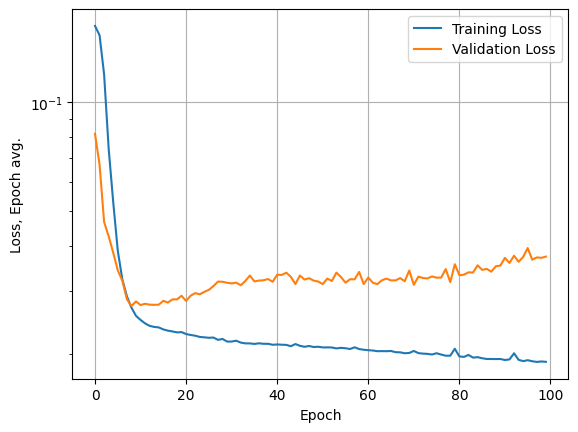

In [15]:
# Plot loss curve
plt.plot(training_losses, label = "Training Loss")
plt.plot(validation_losses, label = "Validation Loss")
plt.ylabel("Loss, Epoch avg.")
plt.xlabel("Epoch")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

### **Retraining with Optimized Parameters**

In [16]:
raise RuntimeError("Stop full notebook execution here, check if the correct number of ideal epochs ist set for re-training below (if mode == 'training'). Continue executing afterwards.")

RuntimeError: Stop full notebook execution here, check if the correct number of ideal epochs ist set for re-training below (if mode == 'training'). Continue executing afterwards.

In [17]:
if mode == "training":

    # Set according to training vs. validation loss results
    epochs_ideal = 10

    # Initializing empty sets to store loss values
    training_losses = []
    validation_losses = []

    for epoch in range(epochs_ideal):

        # Training Step
        model.train()
        epoch_training_loss_sum = 0.0

        for x_training_batch, y_training_targets_batch in training_batches:

            x_training_batch         = x_training_batch.to(device)
            y_training_targets_batch = y_training_targets_batch.to(device)

            optimizer.zero_grad()

            y_training_predictions_batch = model(x_training_batch)

            batch_training_loss = criterion(
                y_training_predictions_batch,
                y_training_targets_batch,
            )

            batch_training_loss.backward()
            optimizer.step()

            epoch_training_loss_sum += batch_training_loss.item()

        epoch_training_loss_avg = epoch_training_loss_sum / len(training_batches)     # average epoch loss per batch
        training_losses.append(epoch_training_loss_avg)


        model.eval()
        epoch_validation_loss_sum = 0.0

        with torch.no_grad():
        # disables gradient calculation, no gradients for backpropagation needed here

            for x_validation_batch, y_validation_targets_batch in validation_batches:

                x_validation_batch         = x_validation_batch.to(device)
                y_validation_targets_batch = y_validation_targets_batch.to(device)

                y_validation_predictions_batch = model(x_validation_batch)

                validation_batch_loss = criterion(
                    y_validation_predictions_batch,
                    y_validation_targets_batch)

                epoch_validation_loss_sum += validation_batch_loss.item()

    epoch_validation_loss_avg = epoch_validation_loss_sum / len(validation_batches)
    validation_losses.append(epoch_validation_loss_avg)

### **Exporting Model Weights**

In [19]:
# torch.save(model.state_dict(), "LSTM_2x17_weights.pt")

----
## **TESTING**
----

In [ ]:
if mide == "training":
  raise RuntimeError("Below fields are for testing mode only.")

RuntimeError: Stop full notebook execution here, check if the correct number of ideal epochs ist set for re-training below (if mode == 'training'). Continue executing afterwards.

### **Loading Model Weights**

In [ ]:
state_dict = torch.load(
    "LSTM_model_2x17.pt",
    map_location=device
)

model.load_state_dict(state_dict)

### **Calculating Predictions and Metrics**

In [ ]:
y_test_targets_scaled = []
y_test_predictions_scaled = []

# Start testing
model.eval()

with torch.no_grad():

    for x_test_batch, y_test_targets_batch in test_batches:

        x_test_batch        = x_test_batch.to(device)

        # Make the prediction
        y_test_predictions_batch = model(x_test_batch)

        # Collect all y_prediction and y_target batches simultaneously (also works whenthe batches are shuffled)
        y_test_predictions_scaled.append(y_test_predictions_batch.cpu().numpy())
        y_test_targets_scaled.append(y_test_targets_batch.cpu().numpy())


# Transform the collection of np.arrays to a single array for error calculation
y_test_predictions_scaled = np.concatenate(y_test_predictions_scaled, axis=0)
y_test_targets_scaled = np.concatenate(y_test_targets_scaled, axis=0)

# Select the right scaler for the OT signal
scaler_OT = scalers_dict["OT"]

# Convert predictions back to source scale
y_test_predictions = scaler_OT.inverse_transform(y_test_predictions_scaled)
y_test_targets = scaler_OT.inverse_transform(y_test_targets_scaled)

### Calculating metrics
test_mse = mean_squared_error(y_test_targets, y_test_predictions)
test_mae = mean_absolute_error(y_test_targets, y_test_predictions)

print(f"\nTest MSE: {test_mse:.8f}")
print(f"Test MAE: {test_mae:.8f}")

### **Calculating Signal Mean Values to Identify Drift**

In [ ]:
print(f"Training split mean: {training_split["OT"].mean()}")
print(f"Validation split mean: {validation_split["OT"].mean()}")
print(f"Test split mean: {test_split["OT"].mean()}")

print(f"Prediction mean, first prediction: {y_test_predictions[0].mean()}")
print(f"Prediction mean, all predictions: {y_test_predictions.mean()}")
print(f"Test target mean, first prediction: {y_test_targets[0].mean()}")
print(f"Test target mean, all predictions: {y_test_targets.mean()}")

### **Plotting Results**

In [ ]:
# Create time axis, use the input and prediction window as bounds
time = np.arange(-context,forecast, 1)


### Plot the results
plt.figure(figsize=(12, 5))


# Plot inputs
plt.plot(
    time[:context],
    validation_split[-context:]["OT"],
    linewidth=2,
    label="Test inputs",
    color="tab:blue",
)

# Plot targets
plt.plot(
     time[context:(context+forecast)],
     y_test_targets[0],
     linewidth=2,
     label="Test ground truth",
     color="tab:blue",
 )

# Plot predictions
plt.plot(
    time[context:(context+forecast)],
    y_test_predictions[0],
    linewidth=2,
    label="Test prediction",
    color="tab:orange",
)

# # Check: plot targets from source data
# plt.plot(
#      time[context:(context+forecast)],
#      test_split[:forecast]["OT"],
#      linewidth=2,
#      label="Test ground truth from source",
#      color="tab:red",
#  )


plt.xlabel("Time (h)")
plt.ylabel("OT")

plt.legend()
plt.tight_layout()
plt.show()